# Análisis exploratorio de datos

Contentesta las siguientes preguntas escribiendo el código de Python necesario para encontrar las respuestas o producir las gráficas necesarias

---


In [1]:
# No mostrar advertencias
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

### 1. ¿Cuál es la distribución de edades de los clientes?
- **Objetivo**: Comprender la distribución de las edades en el conjunto de datos.
- **Respuesta esperada**: Un histograma de la columna Age.

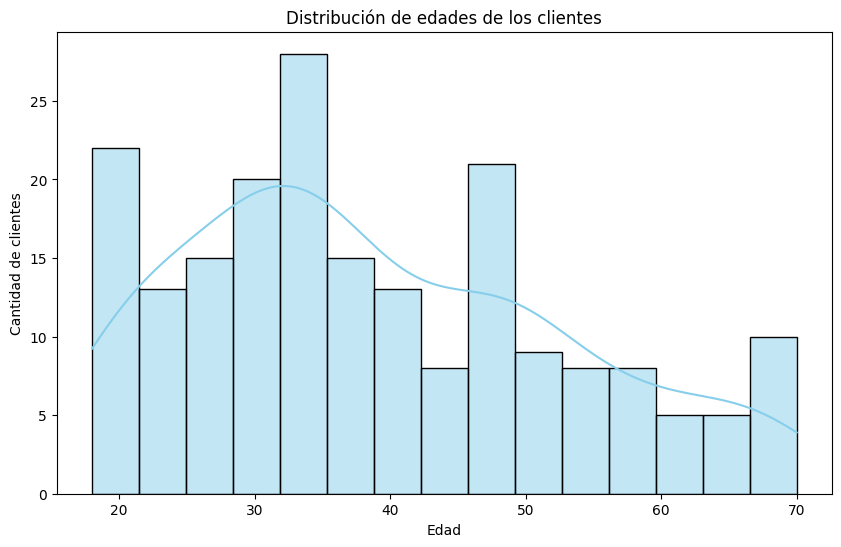

In [2]:
# Cargar los datos
df = pd.read_csv('data/retailmax.csv')

# Verificar los primeros registros
df.head()

# Histograma de la distribución de edades
plt.figure(figsize=(10,6))
sns.histplot(df['Age'], bins=15, kde=True, color='skyblue')
plt.title('Distribución de edades de los clientes')
plt.xlabel('Edad')
plt.ylabel('Cantidad de clientes')
plt.show()

### 2. ¿Existen diferencias significativas en los ingresos anuales entre hombres y mujeres?
- **Objetivo**: Comparar la distribución de ingresos anuales entre géneros.
- **Respuesta esperada**: Una gráfica de cajas (boxplot) que muestre la distribución de Annual Income (k$) por género.

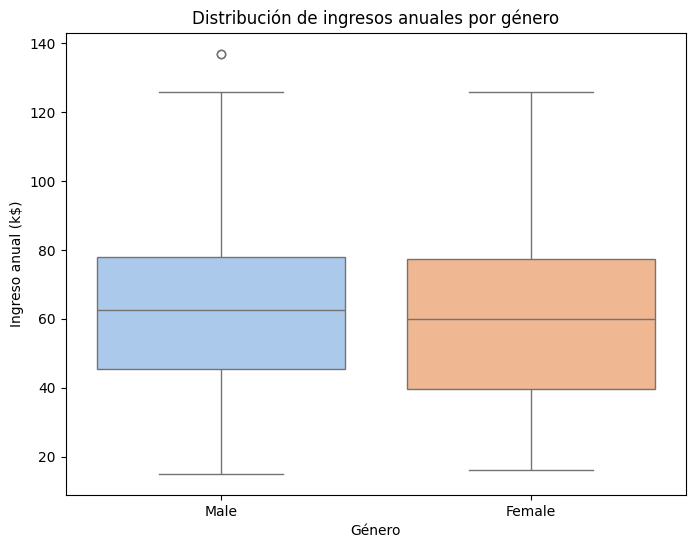

Estadísticas descriptivas de ingresos anuales por género:

        count       mean        std   min    25%   50%    75%    max
Gender                                                              
Female  112.0  59.250000  26.011952  16.0  39.75  60.0  77.25  126.0
Male     88.0  62.227273  26.638373  15.0  45.50  62.5  78.00  137.0


In [3]:
# Boxplot de ingresos anuales por género
plt.figure(figsize=(8,6))
sns.boxplot(x='Gender', y='Annual Income (k$)', data=df, palette='pastel')
plt.title('Distribución de ingresos anuales por género')
plt.xlabel('Género')
plt.ylabel('Ingreso anual (k$)')
plt.show()

# Estadísticas descriptivas por género
stats_ingresos = df.groupby('Gender')['Annual Income (k$)'].describe()
print("Estadísticas descriptivas de ingresos anuales por género:\n")
print(stats_ingresos)

### 3. ¿Cómo se distribuye la puntuación de gasto (Spending Score) entre los diferentes rangos de edad?
- **Objetivo**: Analizar la relación entre la edad y la puntuación de gasto.
- **Respuesta esperada**: Una gráfica de dispersión (scatter plot) o un gráfico de cajas que compare la Spending Score (1-100) con diferentes grupos de edad.

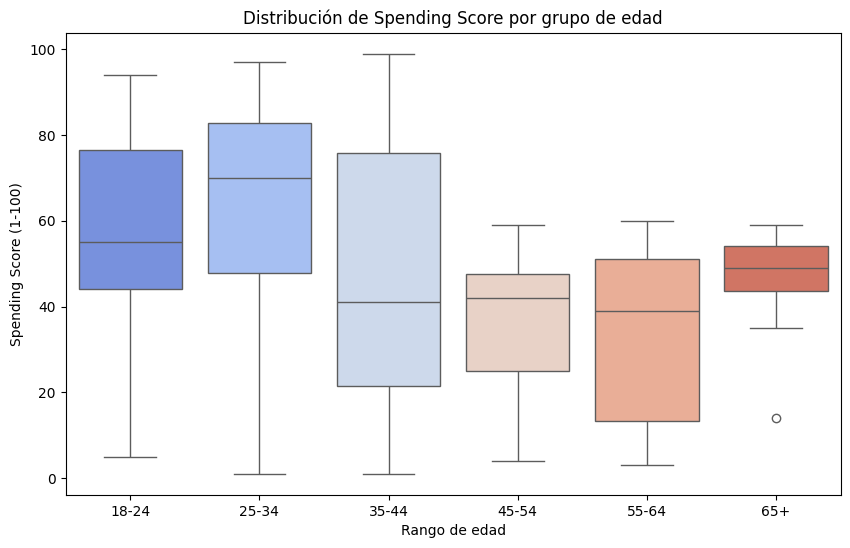

In [4]:
# Crear rangos de edad
bins = [18, 25, 35, 45, 55, 65, 100]  # Ajusta según el rango de tus clientes
labels = ['18-24','25-34','35-44','45-54','55-64','65+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Boxplot de Spending Score por grupo de edad
plt.figure(figsize=(10,6))
sns.boxplot(x='AgeGroup', y='Spending Score (1-100)', data=df, palette='coolwarm')
plt.title('Distribución de Spending Score por grupo de edad')
plt.xlabel('Rango de edad')
plt.ylabel('Spending Score (1-100)')
plt.show()

### 4. ¿Cuál es la correlación entre el ingreso anual y la puntuación de gasto?
- **Objetivo**: Identificar si existe una relación lineal entre el ingreso y el gasto.
- **Respuesta esperada**: Una gráfica de dispersión y el cálculo del coeficiente de correlación entre Annual Income (k$) y Spending Score (1-100).

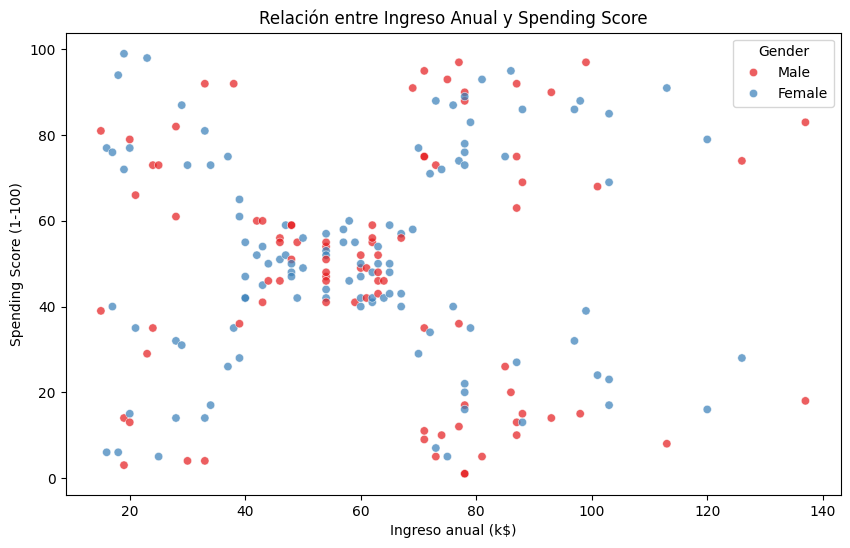

Coeficiente de correlación entre ingreso anual y Spending Score: 0.01


In [5]:
# Gráfico de dispersión: Ingreso anual vs Spending Score
plt.figure(figsize=(10,6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df, hue='Gender', palette='Set1', alpha=0.7)
plt.title('Relación entre Ingreso Anual y Spending Score')
plt.xlabel('Ingreso anual (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

# Cálculo del coeficiente de correlación de Pearson
correlation = df['Annual Income (k$)'].corr(df['Spending Score (1-100)'])
print(f"Coeficiente de correlación entre ingreso anual y Spending Score: {correlation:.2f}")

### 5. ¿Cómo varía la puntuación de gasto en diferentes grupos de ingresos anuales?
- **Objetivo**: Examinar cómo los clientes en diferentes rangos de ingresos se comportan en términos de gasto.
- **Respuesta esperada**: Una gráfica de cajas o de violín que muestre la Spending Score (1-100) para diferentes rangos de Annual Income (k$).

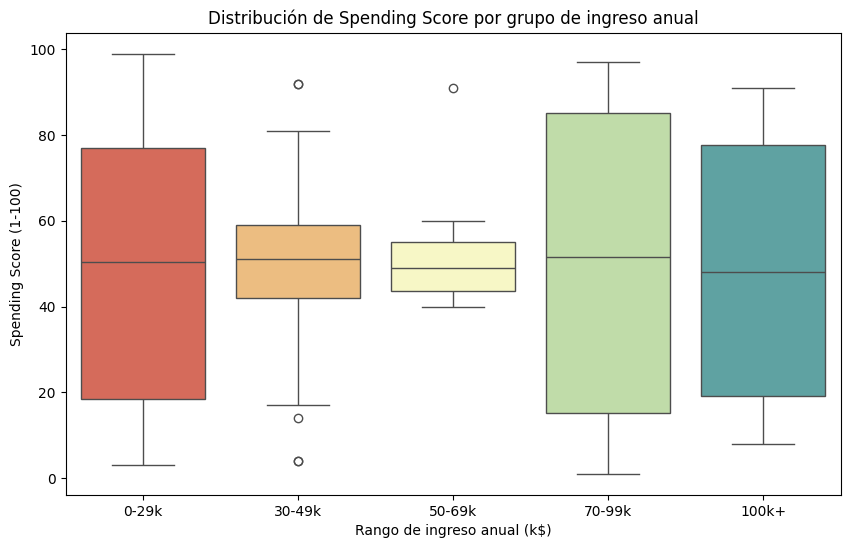

Estadísticas descriptivas de Spending Score por grupo de ingreso:

             count       mean        std   min    25%   50%    75%   max
IncomeGroup                                                             
0-29k         30.0  50.400000  32.149007   3.0  18.50  50.5  77.00  99.0
30-49k        42.0  50.000000  19.473559   4.0  42.00  51.0  59.00  92.0
50-69k        52.0  50.153846   8.256630  40.0  43.75  49.0  55.00  91.0
70-99k        62.0  50.596774  34.036364   1.0  15.25  51.5  85.25  97.0
100k+         14.0  48.785714  31.620778   8.0  19.25  48.0  77.75  91.0


In [6]:
# Crear rangos de ingresos anuales
income_bins = [0, 30, 50, 70, 100, 200]  # Ajusta según los ingresos de tus clientes
income_labels = ['0-29k','30-49k','50-69k','70-99k','100k+']
df['IncomeGroup'] = pd.cut(df['Annual Income (k$)'], bins=income_bins, labels=income_labels, right=False)

# Boxplot de Spending Score por grupo de ingreso
plt.figure(figsize=(10,6))
sns.boxplot(x='IncomeGroup', y='Spending Score (1-100)', data=df, palette='Spectral')
plt.title('Distribución de Spending Score por grupo de ingreso anual')
plt.xlabel('Rango de ingreso anual (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

# Estadísticas descriptivas por grupo de ingreso
stats_spending_income = df.groupby('IncomeGroup')['Spending Score (1-100)'].describe()
print("Estadísticas descriptivas de Spending Score por grupo de ingreso:\n")
print(stats_spending_income)

### 6. ¿Cuál es la proporción de clientes por género?
- **Objetivo**: Determinar el balance de género en el conjunto de datos.
- **Respuesta esperada**: Una gráfica de barras o un gráfico de pastel que muestre la proporción de hombres y mujeres.

Cantidad de clientes por género:

Gender
Female    112
Male       88
Name: count, dtype: int64


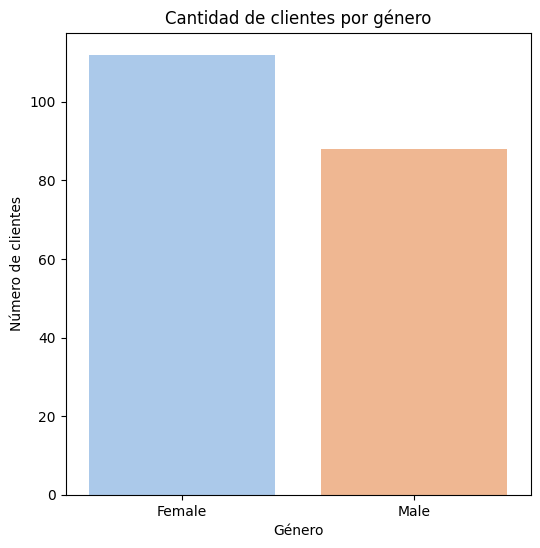

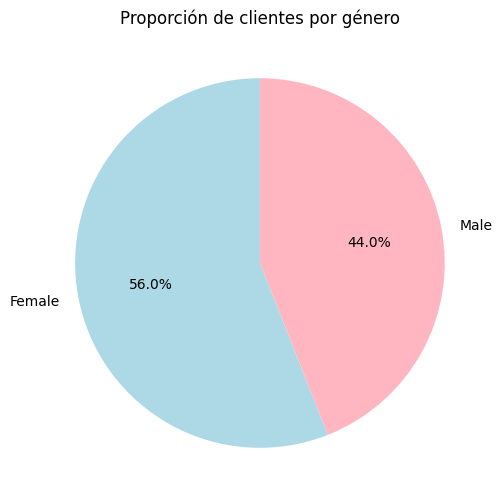

In [7]:
# Contar la cantidad de clientes por género
gender_counts = df['Gender'].value_counts()
print("Cantidad de clientes por género:\n")
print(gender_counts)

# Gráfico de barras
plt.figure(figsize=(6,6))
sns.barplot(x=gender_counts.index, y=gender_counts.values, palette='pastel')
plt.title('Cantidad de clientes por género')
plt.xlabel('Género')
plt.ylabel('Número de clientes')
plt.show()

# Gráfico de pastel
plt.figure(figsize=(6,6))
plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', colors=['lightblue','lightpink'], startangle=90)
plt.title('Proporción de clientes por género')
plt.show()

### 7. ¿Qué grupos de edad gastan más en promedio?
- **Objetivo**: Identificar los grupos de edad que tienen una mayor puntuación de gasto en promedio.
- **Respuesta esperada**: Una gráfica de barras que compare la puntuación de gasto promedio entre diferentes grupos de edad.

Spending Score promedio por grupo de edad:

AgeGroup
18-24    56.257143
25-34    63.166667
35-44    49.428571
45-54    36.230769
55-64    32.312500
65+      46.714286
Name: Spending Score (1-100), dtype: float64


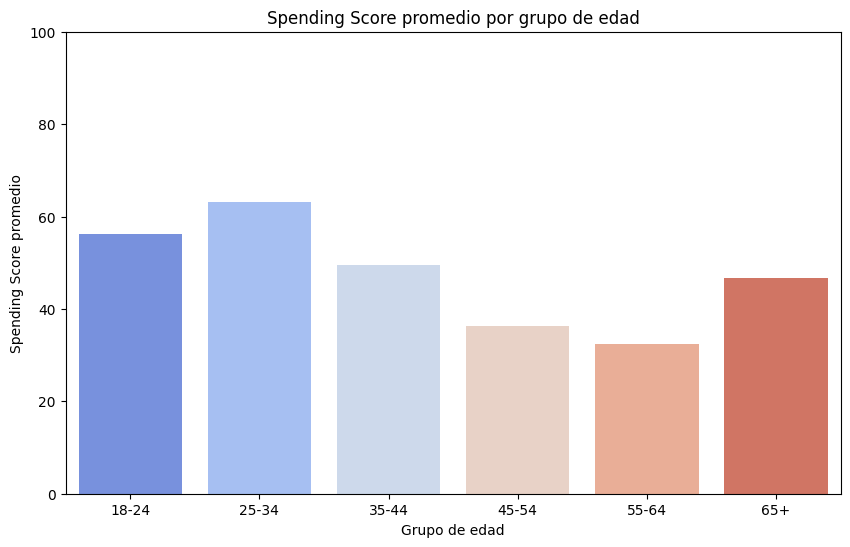

In [8]:
# Calcular la media de Spending Score por grupo de edad
avg_spending_by_age = df.groupby('AgeGroup')['Spending Score (1-100)'].mean().sort_index()
print("Spending Score promedio por grupo de edad:\n")
print(avg_spending_by_age)

# Gráfico de barras
plt.figure(figsize=(10,6))
sns.barplot(x=avg_spending_by_age.index, y=avg_spending_by_age.values, palette='coolwarm')
plt.title('Spending Score promedio por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Spending Score promedio')
plt.ylim(0,100)  # Escala del score
plt.show()

### 8. ¿Hay alguna relación entre la edad y el ingreso anual de los clientes?
- **Objetivo**: Explorar si hay una tendencia entre la edad de los clientes y sus ingresos.
- **Respuesta esperada**: Una gráfica de dispersión que muestre la relación entre Age y Annual Income (k$).

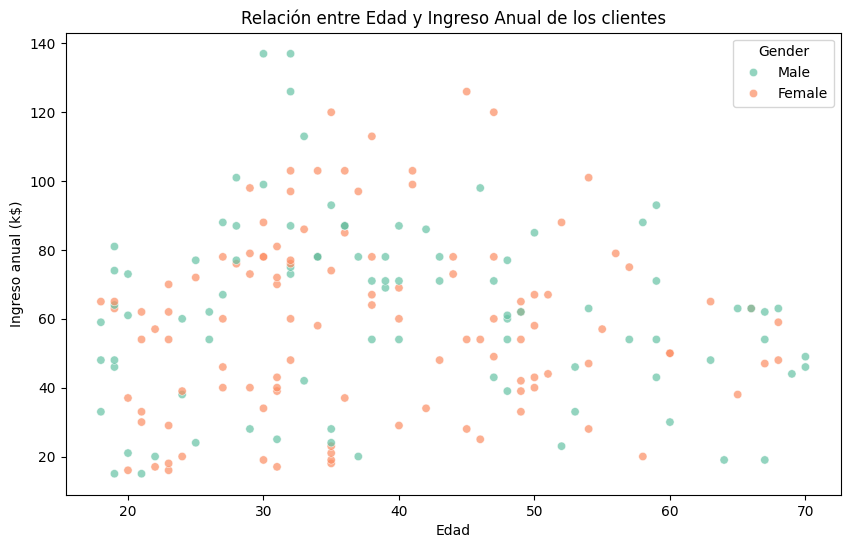

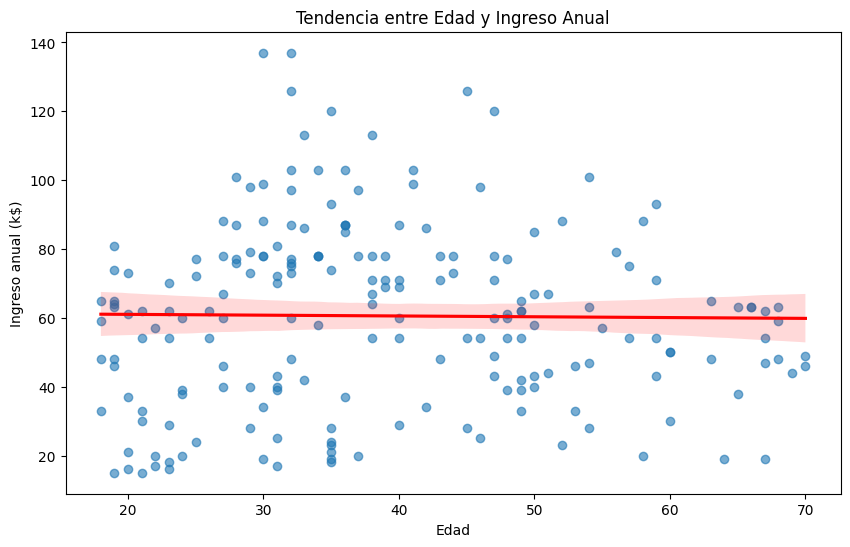

Coeficiente de correlación entre Edad y Ingreso Anual: -0.01


In [9]:
# Gráfico de dispersión: Edad vs Ingreso anual
plt.figure(figsize=(10,6))
sns.scatterplot(x='Age', y='Annual Income (k$)', data=df, hue='Gender', palette='Set2', alpha=0.7)
plt.title('Relación entre Edad y Ingreso Anual de los clientes')
plt.xlabel('Edad')
plt.ylabel('Ingreso anual (k$)')
plt.show()

# Scatter plot con línea de tendencia
plt.figure(figsize=(10,6))
sns.regplot(x='Age', y='Annual Income (k$)', data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Tendencia entre Edad y Ingreso Anual')
plt.xlabel('Edad')
plt.ylabel('Ingreso anual (k$)')
plt.show()

# Cálculo del coeficiente de correlación de Pearson
correlation_age_income = df['Age'].corr(df['Annual Income (k$)'])
print(f"Coeficiente de correlación entre Edad y Ingreso Anual: {correlation_age_income:.2f}")

### 9. ¿Cuál es la distribución conjunta de la edad y el ingreso anual?
- **Objetivo**: Entender cómo se distribuyen estas dos variables en conjunto.
- **Respuesta esperada**: Una gráfica de dispersión con una densidad de puntos o un gráfico de hexágonos que muestre la distribución conjunta de Age y Annual Income (k$).

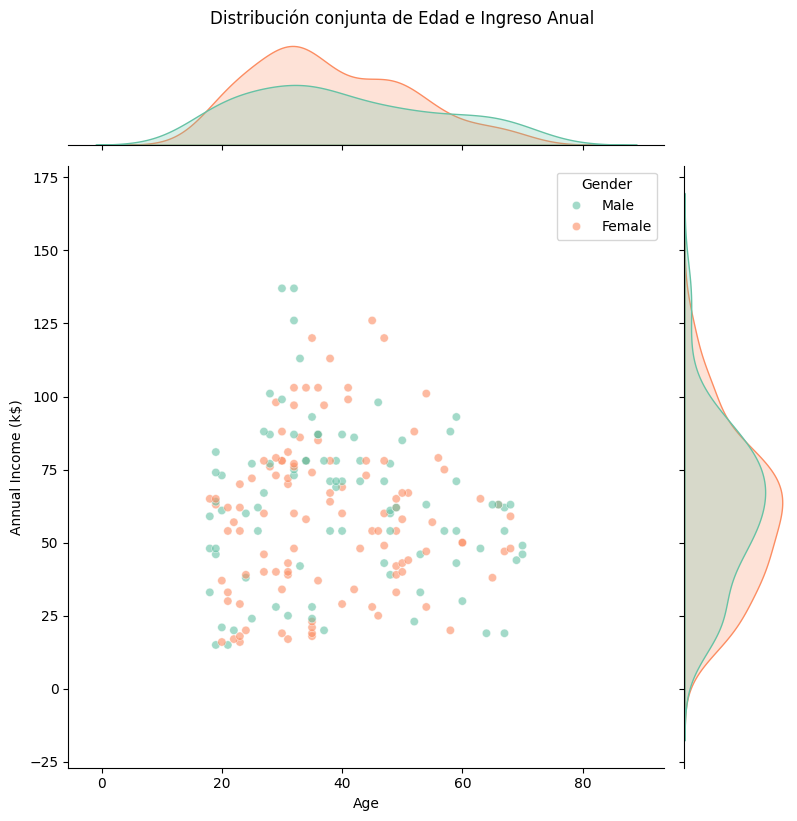

In [ ]:
# Jointplot de Edad vs Ingreso anual
sns.jointplot(
    x='Age', 
    y='Annual Income (k$)', 
    data=df, 
    kind='scatter',  
    hue='Gender',    
    palette='Set2',
    height=8,
    alpha=0.6
)
plt.suptitle('Distribución conjunta de Edad e Ingreso Anual', y=1.02)
plt.show()

### 10. ¿Cómo se distribuyen los clientes en función de la puntuación de gasto y el género?
- **Objetivo**: Analizar la relación entre la puntuación de gasto y el género.
- **Respuesta esperada**: Una gráfica de dispersión o un gráfico de violín que muestre la Spending Score (1-100) separada por género.

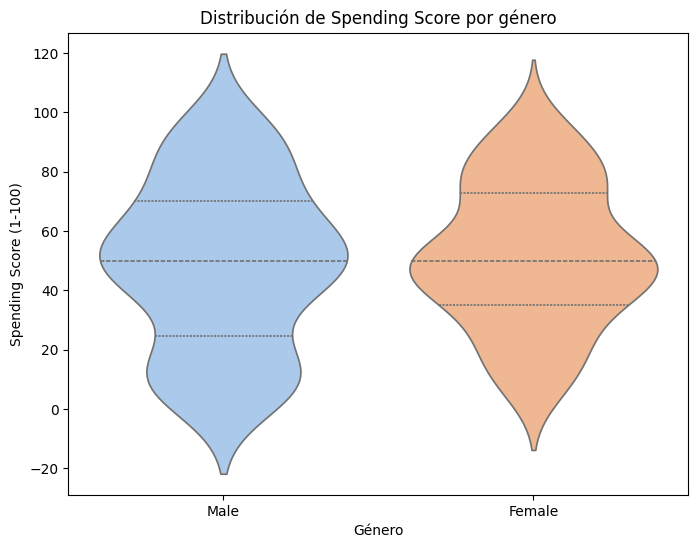

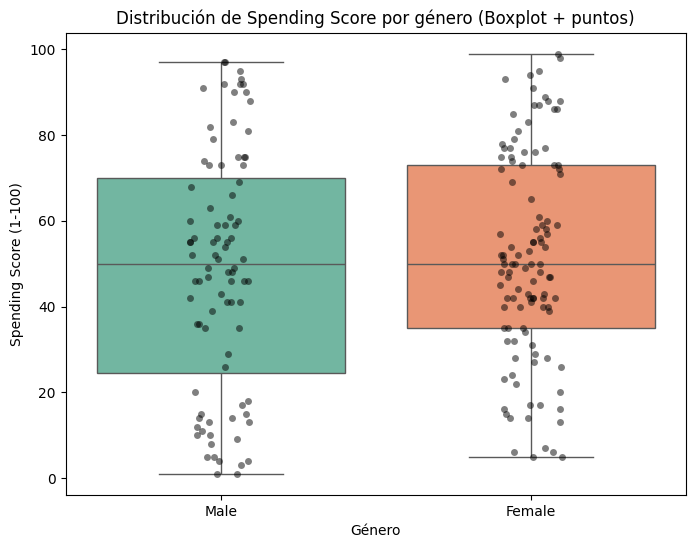

Estadísticas descriptivas de Spending Score por género:

        count       mean       std  min   25%   50%   75%   max
Gender                                                         
Female  112.0  51.526786  24.11495  5.0  35.0  50.0  73.0  99.0
Male     88.0  48.511364  27.89677  1.0  24.5  50.0  70.0  97.0


In [11]:
# Violin plot de Spending Score por género
plt.figure(figsize=(8,6))
sns.violinplot(x='Gender', y='Spending Score (1-100)', data=df, palette='pastel', inner='quartile')
plt.title('Distribución de Spending Score por género')
plt.xlabel('Género')
plt.ylabel('Spending Score (1-100)')
plt.show()

# Alternativa: boxplot con puntos individuales
plt.figure(figsize=(8,6))
sns.boxplot(x='Gender', y='Spending Score (1-100)', data=df, palette='Set2')
sns.stripplot(x='Gender', y='Spending Score (1-100)', data=df, color='black', alpha=0.5, jitter=True)
plt.title('Distribución de Spending Score por género (Boxplot + puntos)')
plt.xlabel('Género')
plt.ylabel('Spending Score (1-100)')
plt.show()

# Estadísticas descriptivas por género
stats_spending_gender = df.groupby('Gender')['Spending Score (1-100)'].describe()
print("Estadísticas descriptivas de Spending Score por género:\n")
print(stats_spending_gender)